<a href="https://colab.research.google.com/github/dnhshl/cc-ai/blob/main/HuggingFaceIntro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Einführung in Hugging Face
Hugging Face ist eine Plattform und Community für maschinelles Lernen, die sich auf natürliche Sprachverarbeitung (NLP) und Computer Vision spezialisiert hat. Hugging Face bietet:
* Eine umfangreiche Bibliothek vortrainierter Modelle
* Die Transformers-Bibliothek für einfachen Zugriff auf State-of-the-Art-Modelle
* Datasets-Bibliothek für den Zugriff auf öffentliche Datensätze
* Spaces für das Deployment von ML-Anwendungen
* Eine aktive Community zum Austausch von Modellen und Wissen

### Erkunden Sie Hugging Face

1. Öffnen Sie einen Webbrowser und navigieren Sie zu [Hugging Face](https://huggingface.co/)
2. Erstellen Sie ein kostenloses Konto (falls Sie noch keines haben)
3. Erkunden Sie die Hauptbereiche der Plattform:
* Models: Vortrainierte Modelle
* Datasets: Öffentliche Datensätze
* Spaces: Deployments von ML-Anwendungen

### Erkundung vortrainierter Modelle
1. Navigieren Sie zu [Hugging Face Models](https://huggingface.co/models)
2. Filtern Sie nach Modellen für eine bestimmte Aufgabe (z.B. "Text Classification")
3. Öffnen Sie ein Modell und erkunden Sie dessen Beschreibung, Nutzung und Leistung

In [ ]:
from transformers import pipeline

# Laden eines vortrainierten Modells für Stimmungsanalyse
english_classifier = pipeline('sentiment-analysis')

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

classifier = pipeline("text-classification", model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")

Device set to use cpu


In [ ]:
# Testen des Modells mit einigen Beispieltexten
texte = [
    # 1*
    "I bought the black sneakers as shown in the photos. The item sent to me were the checked sneakers. In order to return it overseas it will cost $171.",
    # 2*
    "Shoe looks good but the getting it the shoe is very cramped and wasn't much space for my toes to stretch.",
    # 3*
    "Nice looking footwear , not very comfortable very flat soled",
    # 4*
    "Got 8 months daily use out of them. Bottoms worn now but still usable, I have now got a new pair as a daily.",
    # 5*
    "Excellent! Lightweight & stylish. Perfect for the summer months."
]

for text in texte:
    result = classifier(text)
    print(f"Text: {text}")
    print(f"Stimmung: {result[0]['label']}, Konfidenz: {result[0]['score']:.4f}")
    print("-" * 50)

Text: I bought the black sneakers as shown in the photos. The item sent to me were the checked sneakers. In order to return it overseas it will cost $171.
Stimmung: NEGATIVE, Konfidenz: 0.9963
--------------------------------------------------
Text: Shoe looks good but the getting it the shoe is very cramped and wasn't much space for my toes to stretch.
Stimmung: NEGATIVE, Konfidenz: 0.9992
--------------------------------------------------
Text: Nice looking footwear , not very comfortable very flat soled
Stimmung: POSITIVE, Konfidenz: 0.9759
--------------------------------------------------
Text: Got 8 months daily use out of them. Bottoms worn now but still usable, I have now got a new pair as a daily.
Stimmung: NEGATIVE, Konfidenz: 0.9646
--------------------------------------------------
Text: Excellent! Lightweight & stylish. Perfect for the summer months.
Stimmung: POSITIVE, Konfidenz: 0.9999
--------------------------------------------------


In [ ]:
# Laden eines mehrsprachigen Modells für Stimmungsanalyse
classifier = pipeline('sentiment-analysis', model="nlptown/bert-base-multilingual-uncased-sentiment")



config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


Text: Dieser Kurs ist wirklich hervorragend!
Bewertung: 5 stars
--------------------------------------------------
Text: Die Erklärungen sind verständlich und hilfreich.
Bewertung: 5 stars
--------------------------------------------------
Text: Ich verstehe die Aufgabenstellung nicht.
Bewertung: 1 star
--------------------------------------------------


In [ ]:
# Testen des Modells mit deutschen Texten
texte = [
    "Dieser Kurs ist wirklich hervorragend!",
    "Die Erklärungen sind verständlich und hilfreich.",
    "Ich verstehe die Aufgabenstellung nicht."
]

for text in texte:
    result = classifier(text)
    print(f"Text: {text}")
    print(f"Bewertung: {result[0]['label']}")
    print("-" * 50)

Text: Dieser Kurs ist wirklich hervorragend!
Bewertung: 5 stars
--------------------------------------------------
Text: Die Erklärungen sind verständlich und hilfreich.
Bewertung: 5 stars
--------------------------------------------------
Text: Ich verstehe die Aufgabenstellung nicht.
Bewertung: 1 star
--------------------------------------------------


In [1]:
from transformers import pipeline
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO


In [2]:
# Laden eines vortrainierten Bildklassifikationsmodells
classifier = pipeline("image-classification")

# Beispielbild laden
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
response = requests.get(url)
image = Image.open(BytesIO(response.content))

No model was supplied, defaulted to google/vit-base-patch16-224 and revision 3f49326 (https://huggingface.co/google/vit-base-patch16-224).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


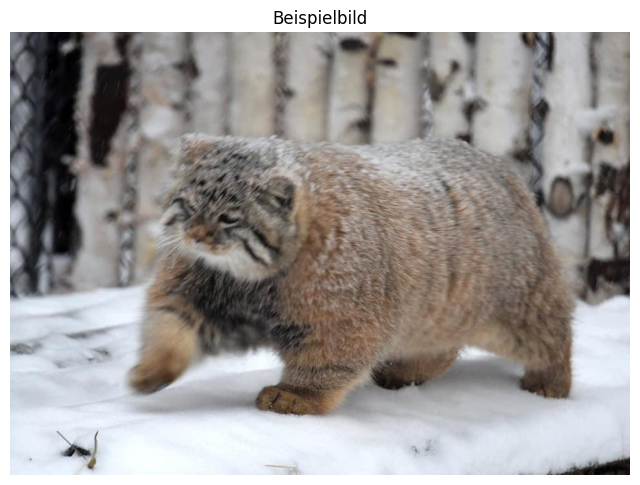

In [3]:
# Bild anzeigen
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis('off')
plt.title("Beispielbild")
plt.show()


In [5]:
# Bildklassifikation durchführen
results = classifier(image)

# Ergebnisse anzeigen
print("Erkannte Objekte:")
for result in results:
    print(f"- {result['label']} (Konfidenz: {result['score']:.4f})")

Erkannte Objekte:
- lynx, catamount (Konfidenz: 0.4335)
- cougar, puma, catamount, mountain lion, painter, panther, Felis concolor (Konfidenz: 0.0348)
- snow leopard, ounce, Panthera uncia (Konfidenz: 0.0324)
- Egyptian cat (Konfidenz: 0.0239)
- tiger cat (Konfidenz: 0.0229)


In [6]:
from transformers import pipeline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import requests
from io import BytesIO


In [7]:
# Laden eines vortrainierten Objekterkennungsmodells
detector = pipeline("object-detection")

No model was supplied, defaulted to facebook/detr-resnet-50 and revision 1d5f47b (https://huggingface.co/facebook/detr-resnet-50).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/4.59k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


In [8]:
# Objekterkennung durchführen
results = detector(image)

Erkannte Objekte:
- cat (Konfidenz: 0.9864, Position: {'xmin': 178, 'ymin': 154, 'xmax': 882, 'ymax': 598})


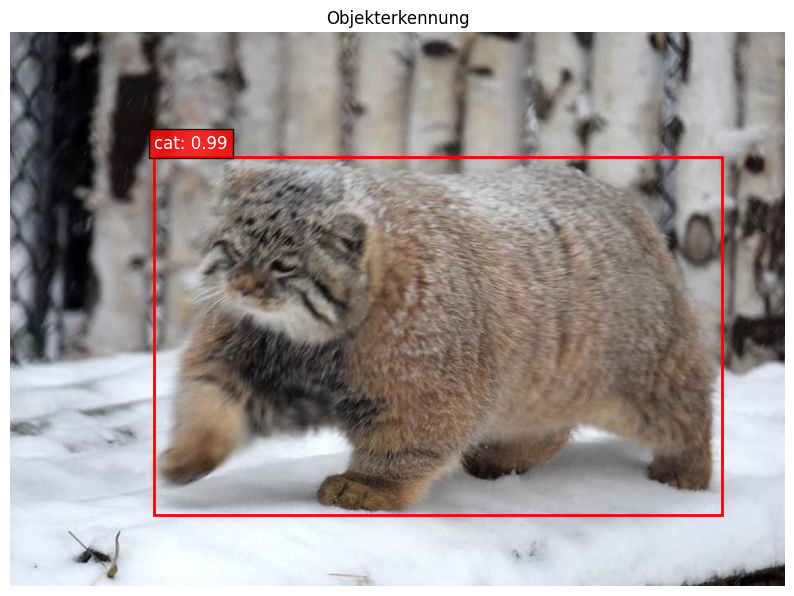

In [9]:
# Ergebnisse anzeigen
print("Erkannte Objekte:")
for result in results:
    print(f"- {result['label']} (Konfidenz: {result['score']:.4f}, Position: {result['box']})")

# Bild mit Bounding Boxes anzeigen
plt.figure(figsize=(10, 10))
plt.imshow(image)
ax = plt.gca()

for result in results:
    box = result['box']
    x, y, width, height = box['xmin'], box['ymin'], box['xmax'] - box['xmin'], box['ymax'] - box['ymin']

    # Bounding Box zeichnen
    rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

    # Label hinzufügen
    plt.text(x, y-10, f"{result['label']}: {result['score']:.2f}", color='white',
             bbox=dict(facecolor='red', alpha=0.8), fontsize=12)

plt.axis('off')
plt.title("Objekterkennung")
plt.show()

In [11]:
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import io

Saving ford-3244350_640.jpg to ford-3244350_640.jpg


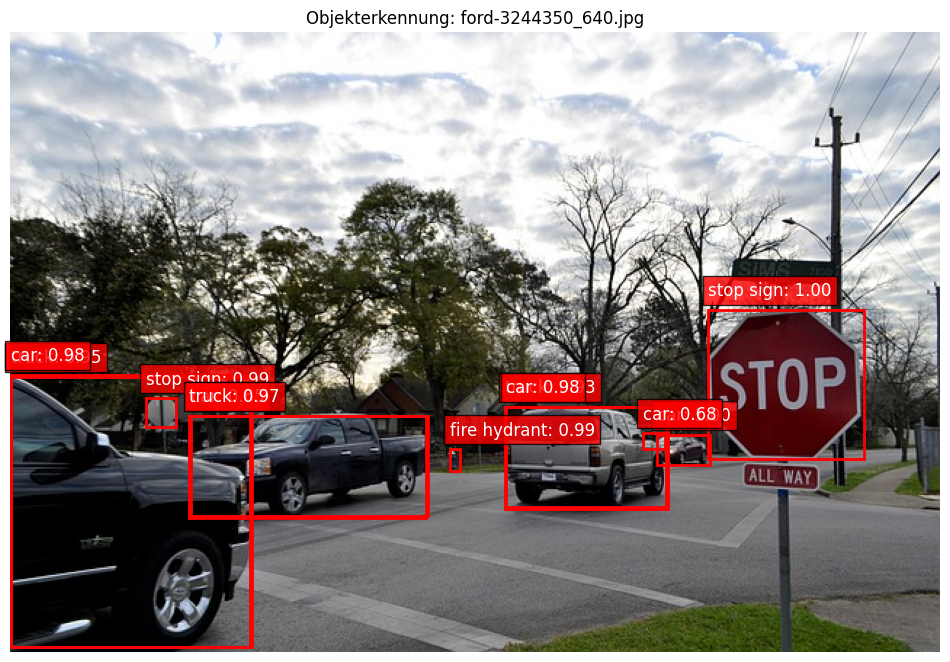

Erkannte Objekte in ford-3244350_640.jpg:
- truck (Konfidenz: 0.9537, Position: {'xmin': 0, 'ymin': 237, 'xmax': 166, 'ymax': 423})
- stop sign (Konfidenz: 0.9987, Position: {'xmin': 480, 'ymin': 191, 'xmax': 587, 'ymax': 294})
- stop sign (Konfidenz: 0.9946, Position: {'xmin': 93, 'ymin': 252, 'xmax': 114, 'ymax': 272})
- car (Konfidenz: 0.9955, Position: {'xmin': 445, 'ymin': 277, 'xmax': 481, 'ymax': 298})
- car (Konfidenz: 0.6785, Position: {'xmin': 435, 'ymin': 276, 'xmax': 450, 'ymax': 287})
- car (Konfidenz: 0.6484, Position: {'xmin': 124, 'ymin': 264, 'xmax': 287, 'ymax': 333})
- truck (Konfidenz: 0.9681, Position: {'xmin': 123, 'ymin': 264, 'xmax': 286, 'ymax': 334})
- car (Konfidenz: 0.9766, Position: {'xmin': 0, 'ymin': 236, 'xmax': 165, 'ymax': 423})
- fire hydrant (Konfidenz: 0.9910, Position: {'xmin': 302, 'ymin': 287, 'xmax': 309, 'ymax': 302})
- truck (Konfidenz: 0.9343, Position: {'xmin': 340, 'ymin': 258, 'xmax': 452, 'ymax': 328})
- car (Konfidenz: 0.9824, Position: 

In [13]:
# Funktion zur Objekterkennung in hochgeladenen Bildern
def detect_objects_in_uploaded_image():
    # Bild hochladen
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Bild öffnen
        image = Image.open(io.BytesIO(uploaded[filename]))

        # Objekterkennung durchführen
        results = detector(image)

        # Bild mit Bounding Boxes anzeigen
        plt.figure(figsize=(12, 12))
        plt.imshow(image)
        ax = plt.gca()

        for result in results:
            box = result['box']
            x, y, width, height = box['xmin'], box['ymin'], box['xmax'] - box['xmin'], box['ymax'] - box['ymin']

            # Bounding Box zeichnen
            rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

            # Label hinzufügen
            plt.text(x, y-10, f"{result['label']}: {result['score']:.2f}", color='white',
                     bbox=dict(facecolor='red', alpha=0.8), fontsize=12)

        plt.axis('off')
        plt.title(f"Objekterkennung: {filename}")
        plt.show()

        # Ergebnisse anzeigen
        print(f"Erkannte Objekte in {filename}:")
        for result in results:
            print(f"- {result['label']} (Konfidenz: {result['score']:.4f}, Position: {result['box']})")

# Funktion aufrufen
detect_objects_in_uploaded_image()

In [15]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.3 MB/s eta 0:00:00


In [16]:
import gradio as gr
from transformers import pipeline

# Laden des Bildklassifikationsmodells
classifier = pipeline("image-classification")

# Funktion für die Gradio-Schnittstelle
def classify_image(image):
    # Bildklassifikation durchführen
    results = classifier(image)

    # Ergebnisse formatieren
    return {result['label']: result['score'] for result in results[:5]}

# Gradio-Oberfläche erstellen
demo = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=5),
    title="Bildklassifikation mit Transformers",
    description="Laden Sie ein Bild hoch, um es zu klassifizieren."
)

# Demo starten
demo.launch()

No model was supplied, defaulted to google/vit-base-patch16-224 and revision 3f49326 (https://huggingface.co/google/vit-base-patch16-224).
Using a pipeline without specifying a model name and revision in production is not recommended.
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4a9fddbbec397f6088.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [17]:
import gradio as gr
from transformers import pipeline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import io

# Laden des Objekterkennungsmodells
detector = pipeline("object-detection")

# Funktion zur Visualisierung der erkannten Objekte
def visualize_detection(image, results):
    # Konvertieren des Bildes in ein numpy-Array, falls es noch keines ist
    if isinstance(image, Image.Image):
        image_array = np.array(image)
    else:
        image_array = image

    # Erstellen einer Matplotlib-Figur
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image_array)

    # Zeichnen der Bounding Boxes
    for result in results:
        box = result['box']
        x, y, width, height = box['xmin'], box['ymin'], box['xmax'] - box['xmin'], box['ymax'] - box['ymin']

        # Bounding Box zeichnen
        rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        # Label hinzufügen
        ax.text(x, y-10, f"{result['label']}: {result['score']:.2f}", color='white',
                bbox=dict(facecolor='red', alpha=0.8), fontsize=12)

    ax.axis('off')

    # Konvertieren der Matplotlib-Figur in ein Bild
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    buf.seek(0)
    img = Image.open(buf)
    plt.close(fig)

    return img

# Funktion für die Gradio-Schnittstelle
def detect_objects(image):
    # Objekterkennung durchführen
    results = detector(image)

    # Bild mit Bounding Boxes erstellen
    output_image = visualize_detection(image, results)

    # Ergebnisse als Text formatieren
    output_text = ""
    for i, result in enumerate(results):
        output_text += f"{i+1}. {result['label']} (Konfidenz: {result['score']:.4f})\n"

    return output_image, output_text

# Gradio-Oberfläche erstellen
demo = gr.Interface(
    fn=detect_objects,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Image(type="pil", label="Erkannte Objekte"),
        gr.Textbox(label="Ergebnisse")
    ],
    title="Objekterkennung mit Transformers",
    description="Laden Sie ein Bild hoch, um Objekte zu erkennen."
)

# Demo starten
demo.launch()

No model was supplied, defaulted to facebook/detr-resnet-50 and revision 1d5f47b (https://huggingface.co/facebook/detr-resnet-50).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a 

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9dd738a35f89cf2a19.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [18]:
import gradio as gr
from transformers import pipeline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import io

# Laden des Objekterkennungsmodells
detector = pipeline("object-detection")

# Funktion zur Visualisierung der erkannten Objekte
def visualize_detection(image, results, confidence_threshold):
    # Konvertieren des Bildes in ein numpy-Array, falls es noch keines ist
    if isinstance(image, Image.Image):
        image_array = np.array(image)
    else:
        image_array = image

    # Filtern der Ergebnisse basierend auf dem Konfidenzschwellenwert
    filtered_results = [result for result in results if result['score'] >= confidence_threshold]

    # Erstellen einer Matplotlib-Figur
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image_array)

    # Zeichnen der Bounding Boxes
    for result in filtered_results:
        box = result['box']
        x, y, width, height = box['xmin'], box['ymin'], box['xmax'] - box['xmin'], box['ymax'] - box['ymin']

        # Bounding Box zeichnen
        rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        # Label hinzufügen
        ax.text(x, y-10, f"{result['label']}: {result['score']:.2f}", color='white',
                bbox=dict(facecolor='red', alpha=0.8), fontsize=12)

    ax.axis('off')

    # Konvertieren der Matplotlib-Figur in ein Bild
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    buf.seek(0)
    img = Image.open(buf)
    plt.close(fig)

    return img

# Funktion für die Gradio-Schnittstelle
def detect_objects(image, confidence_threshold):
    # Objekterkennung durchführen
    results = detector(image)

    # Bild mit Bounding Boxes erstellen
    output_image = visualize_detection(image, results, confidence_threshold)

    # Ergebnisse als Text formatieren
    filtered_results = [result for result in results if result['score'] >= confidence_threshold]

    output_text = f"Insgesamt {len(filtered_results)} Objekte erkannt (Konfidenzschwelle: {confidence_threshold:.2f}):\n\n"
    for i, result in enumerate(filtered_results):
        output_text += f"{i+1}. {result['label']} (Konfidenz: {result['score']:.4f})\n"

    return output_image, output_text

# Gradio-Oberfläche mit zusätzlichen Optionen erstellen
demo = gr.Interface(
    fn=detect_objects,
    inputs=[
        gr.Image(type="pil", label="Bild hochladen"),
        gr.Slider(minimum=0.0, maximum=1.0, value=0.5, step=0.05, label="Konfidenzschwelle")
    ],
    outputs=[
        gr.Image(type="pil", label="Erkannte Objekte"),
        gr.Textbox(label="Ergebnisse")
    ],
    title="Erweiterte Objekterkennung mit Transformers",
    description="Laden Sie ein Bild hoch und passen Sie die Konfidenzschwelle an, um Objekte zu erkennen."
)

# Beispiele hinzufügen
demo.launch()

No model was supplied, defaulted to facebook/detr-resnet-50 and revision 1d5f47b (https://huggingface.co/facebook/detr-resnet-50).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a 

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b92674dd5f221a5f30.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [19]:
import gradio as gr
from transformers import pipeline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import io

# Funktion zur Visualisierung der erkannten Objekte
def visualize_detection(image, results, confidence_threshold):
    # Konvertieren des Bildes in ein numpy-Array, falls es noch keines ist
    if isinstance(image, Image.Image):
        image_array = np.array(image)
    else:
        image_array = image

    # Filtern der Ergebnisse basierend auf dem Konfidenzschwellenwert
    filtered_results = [result for result in results if result['score'] >= confidence_threshold]

    # Erstellen einer Matplotlib-Figur
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image_array)

    # Zeichnen der Bounding Boxes
    for result in filtered_results:
        box = result['box']
        x, y, width, height = box['xmin'], box['ymin'], box['xmax'] - box['xmin'], box['ymax'] - box['ymin']

        # Bounding Box zeichnen
        rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        # Label hinzufügen
        ax.text(x, y-10, f"{result['label']}: {result['score']:.2f}", color='white',
                bbox=dict(facecolor='red', alpha=0.8), fontsize=12)

    ax.axis('off')

    # Konvertieren der Matplotlib-Figur in ein Bild
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    buf.seek(0)
    img = Image.open(buf)
    plt.close(fig)

    return img

# Funktion für die Gradio-Schnittstelle
def detect_objects(image, model_name, confidence_threshold):
    # Objekterkennungsmodell laden
    if model_name == "Standard (facebook/detr-resnet-50)":
        detector = pipeline("object-detection")
    else:
        detector = pipeline("object-detection", model=model_name)

    # Objekterkennung durchführen
    results = detector(image)

    # Bild mit Bounding Boxes erstellen
    output_image = visualize_detection(image, results, confidence_threshold)

    # Ergebnisse als Text formatieren
    filtered_results = [result for result in results if result['score'] >= confidence_threshold]

    output_text = f"Modell: {model_name}\n"
    output_text += f"Insgesamt {len(filtered_results)} Objekte erkannt (Konfidenzschwelle: {confidence_threshold:.2f}):\n\n"
    for i, result in enumerate(filtered_results):
        output_text += f"{i+1}. {result['label']} (Konfidenz: {result['score']:.4f})\n"

    return output_image, output_text

# Liste der verfügbaren Modelle
available_models = [
    "Standard (facebook/detr-resnet-50)",
    "facebook/detr-resnet-101",
    "hustvl/yolos-tiny"
]

# Gradio-Oberfläche mit Modellauswahl erstellen
demo = gr.Interface(
    fn=detect_objects,
    inputs=[
        gr.Image(type="pil", label="Bild hochladen"),
        gr.Dropdown(available_models, value=available_models[0], label="Modell auswählen"),
        gr.Slider(minimum=0.0, maximum=1.0, value=0.5, step=0.05, label="Konfidenzschwelle")
    ],
    outputs=[
        gr.Image(type="pil", label="Erkannte Objekte"),
        gr.Textbox(label="Ergebnisse")
    ],
    title="Objekterkennung mit verschiedenen Transformer-Modellen",
    description="Wählen Sie ein Modell, laden Sie ein Bild hoch und passen Sie die Konfidenzschwelle an, um Objekte zu erkennen."
)

# Demo starten
demo.launch()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fc0a9325ea30862cda.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
